In [1]:
import importlib
from pathlib import Path
import json
import yaml
import torch
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import numpy as np

import project_main.tokens as project_tokens
import project_main.data as project_data
import project_main.model as project_model
import project_main.checkpoints as project_checkpoints

importlib.invalidate_caches()
importlib.reload(project_tokens)
importlib.reload(project_checkpoints)

<module 'project_main.checkpoints' from '/Users/rohanbuluswar/Desktop/Line Break Project/src/project_main/checkpoints.py'>

In [2]:
RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cpu"
vocab = project_tokens.build_vocab(cfg['task'])
model = project_model.build_model(cfg=cfg, device=device)

checkpoint = project_checkpoints.load_checkpoint(path=CHECKPOINT_PATH, model=model,map_location=device)
model.eval()

Building vocab...
('BOS', 'NEWLINE')


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): TypedModuleList(
    (0): TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name='bloc

In [3]:
# Count at Token_A is num of characters including Token_A
# --> new_line will always have character_count = 0
def count_characters(tokens_list):
    character_count_list = []
    current_count = 0
    for token_id in tokens_list:   
        if token_id == vocab.newline_id:
            current_count = 0
            character_count_list.append(0)
        else:
            token_char_count = project_data.extract_character_count(vocab.decode_token(token_id))
            current_count += token_char_count
            character_count_list.append(current_count)

    return character_count_list


In [4]:
layer = 0

def generate_data(n):
    examples = []

    for _ in range(n):
        batch = project_data.make_batch(task_cfg=cfg['task'], vocab=vocab, batch_size=1, device=device)
        tokens = batch.tokens[0]
        character_counts = count_characters(tokens.tolist())
        examples.append((tokens, character_counts))



    all_activations = []
    all_counts = []
    all_token_ids = []

    def collect_residuals(act, hook):
        # One example per forward pass:
        # act shape = [1, sequence_length, d_model]
        current["residuals"] = act[0].detach().cpu()

    model.eval()


    with torch.no_grad():
        for tokens, counts in examples:


            current = {}

            model.run_with_hooks(
                tokens,
                prepend_bos=False,
                fwd_hooks=[
                    (f"blocks.{layer}.hook_resid_post", collect_residuals),
                ],
            )

            residuals = current["residuals"]

            assert residuals.shape[0] == len(counts)
            assert len(tokens) == len(counts)

            all_activations.append(residuals)
            all_counts.append(torch.tensor(counts, dtype=torch.long))
            all_token_ids.append(torch.tensor(tokens, dtype=torch.long))

    X = torch.cat(all_activations, dim=0).float()
    counts = torch.cat(all_counts, dim=0)
    token_ids = torch.cat(all_token_ids, dim=0)
    return X, counts, token_ids

X_train, counts_train, token_ids_train = generate_data(3_000)
X_val, counts_val, token_ids_val = generate_data(3_000)
X_test, counts_test, token_ids_test = generate_data(3_000)

print(X_train.shape)       # [number_of_tokens, 128]
print(counts_train.shape)  # [number_of_tokens]   


train_scale = X_train.pow(2).mean().sqrt().clamp_min(1e-8)
X_train_scaled = X_train / train_scale
X_val_scaled = X_val / train_scale
X_test_scaled = X_test /train_scale


/var/folders/x8/9zh0cmfx5_z_pj5b1lgj5ylw0000gn/T/ipykernel_62977/2207534790.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_token_ids.append(torch.tensor(tokens, dtype=torch.long))


torch.Size([150000, 128])
torch.Size([150000])


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):
    def __init__(self, d_in: int, d_sae: int):
        super().__init__()

        self.encoder = nn.Linear(d_in, d_sae)
        self.decoder = nn.Linear(d_sae, d_in)

        # Initialize decoder directions to unit length.
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.decoder.weight)
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)
        self.normalize_decoder()

    @torch.no_grad()
    def normalize_decoder(self):
        self.decoder.weight.data = F.normalize(
            self.decoder.weight.data,
            dim=0,
        )

    def encode(self, x):
        # Nonnegative sparse feature activations
        return F.relu(self.encoder(x))

    def decode(self, features):
        return self.decoder(features)

    def forward(self, x):
        features = self.encode(x)
        reconstruction = self.decode(features)
        return reconstruction, features
    
    @torch.no_grad()
    def remove_parallel_decoder_grad(self) -> None:
        """
        Remove the component of each decoder gradient parallel to
        its corresponding unit-norm decoder column.
        """
        W = self.decoder.weight
        grad = W.grad

        if grad is None:
            return

        parallel = (grad * W).sum(
            dim=0,
            keepdim=True,
        ) * W

        grad.sub_(parallel)

In [6]:
from torch.utils.data import DataLoader, TensorDataset

sae_device = 'cpu'

batch_size = 512

train_loader = DataLoader(
    TensorDataset(X_train_scaled),
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_scaled),
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_scaled),
    batch_size=batch_size,
    shuffle=False,
)

sae = SparseAutoencoder(
    d_in=X_train_scaled.shape[1],
    d_sae=512,
).to(sae_device)

optimizer = torch.optim.Adam(
    sae.parameters(),
    lr=3e-4,
)


@torch.no_grad()
def evaluate_sae(
    sae: SparseAutoencoder,
    loader: DataLoader,
    device: torch.device,
    lambda_l1: float,
    activation_threshold: float = 1e-6,
) -> dict[str, float]:
    sae.eval()

    total_squared_error = 0.0
    total_input_elements = 0

    total_abs_feature_activation = 0.0
    total_feature_elements = 0

    total_active_features = 0.0
    total_samples = 0

    feature_ever_active = torch.zeros(
        sae.encoder.out_features,
        dtype=torch.bool,
        device=device,
    )

    for (batch,) in loader:
        batch = batch.to(device)

        reconstruction, features = sae(batch)

        total_squared_error += (
            reconstruction - batch
        ).pow(2).sum().item()

        total_input_elements += batch.numel()

        total_abs_feature_activation += (
            features.abs().sum().item()
        )
        total_feature_elements += features.numel()

        active = features > activation_threshold

        total_active_features += (
            active.sum(dim=1)
            .float()
            .sum()
            .item()
        )

        total_samples += batch.shape[0]
        feature_ever_active |= active.any(dim=0)

    reconstruction_mse = (
        total_squared_error / total_input_elements
    )

    mean_l1 = (
        total_abs_feature_activation
        / total_feature_elements
    )

    mean_l0 = (
        total_active_features / total_samples
    )

    dead_fraction = (
        (~feature_ever_active)
        .float()
        .mean()
        .item()
    )

    objective = (
        reconstruction_mse
        + lambda_l1 * mean_l1
    )

    return {
        "loss": objective,
        "reconstruction": reconstruction_mse,
        "l1": mean_l1,
        "l0": mean_l0,
        "dead_fraction": dead_fraction,
    }


In [7]:
from dataclasses import dataclass
import math
import copy

@dataclass
class TrainingResult:
    lambda_l1: float
    model_state: dict
    best_epoch: int
    best_val_metrics: dict[str, float]
    history: list[dict[str, float]]


def train_one_sae(
    *,
    X_train_scaled: torch.Tensor,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lambda_l1: float,
    d_sae: int,
    device: torch.device,
    num_epochs: int = 50,
    learning_rate: float = 3e-4,
    activation_threshold: float = 1e-6,
    patience: int | None = 8,
    seed: int = 0,
) -> TrainingResult:
    torch.manual_seed(seed)

    d_in = X_train_scaled.shape[1]

    sae = SparseAutoencoder(
        d_in=d_in,
        d_sae=d_sae,
    ).to(device)

    optimizer = torch.optim.Adam(
        sae.parameters(),
        lr=learning_rate,
    )

    best_val_loss = math.inf
    best_epoch = -1
    best_state = None
    best_val_metrics = None

    epochs_without_improvement = 0
    history = []

    for epoch in range(num_epochs):
        sae.train()

        total_squared_error = 0.0
        total_input_elements = 0

        total_abs_feature_activation = 0.0
        total_feature_elements = 0

        total_active_features = 0.0
        total_samples = 0

        for (batch,) in train_loader:
            batch = batch.to(device)

            reconstruction, features = sae(batch)

            reconstruction_loss = F.mse_loss(
                reconstruction,
                batch,
            )

            sparsity_loss = features.abs().mean()

            loss = (
                reconstruction_loss
                + lambda_l1 * sparsity_loss
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()

            sae.remove_parallel_decoder_grad()

            optimizer.step()
            sae.normalize_decoder()

            total_squared_error += (
                reconstruction.detach() - batch
            ).pow(2).sum().item()

            total_input_elements += batch.numel()

            total_abs_feature_activation += (
                features.detach().abs().sum().item()
            )

            total_feature_elements += features.numel()

            total_active_features += (
                (features.detach() > activation_threshold)
                .sum(dim=1)
                .float()
                .sum()
                .item()
            )

            total_samples += batch.shape[0]

        train_reconstruction = (
            total_squared_error
            / total_input_elements
        )

        train_l1 = (
            total_abs_feature_activation
            / total_feature_elements
        )

        train_l0 = (
            total_active_features
            / total_samples
        )

        train_loss = (
            train_reconstruction
            + lambda_l1 * train_l1
        )

        val_metrics = evaluate_sae(
            sae=sae,
            loader=val_loader,
            device=device,
            lambda_l1=lambda_l1,
            activation_threshold=activation_threshold,
        )

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_reconstruction": train_reconstruction,
            "train_l1": train_l1,
            "train_l0": train_l0,
            "val_loss": val_metrics["loss"],
            "val_reconstruction": val_metrics["reconstruction"],
            "val_l1": val_metrics["l1"],
            "val_l0": val_metrics["l0"],
            "val_dead_fraction": val_metrics["dead_fraction"],
        }

        history.append(epoch_record)

        print(
            f"lambda={lambda_l1:.1e} "
            f"epoch={epoch:02d} "
            f"train_recon={train_reconstruction:.5f} "
            f"train_l0={train_l0:.2f} "
            f"val_recon={val_metrics['reconstruction']:.5f} "
            f"val_l0={val_metrics['l0']:.2f} "
            f"dead={val_metrics['dead_fraction']:.2%}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch

            best_state = copy.deepcopy(
                sae.state_dict()
            )

            best_val_metrics = copy.deepcopy(
                val_metrics
            )

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            patience is not None
            and epochs_without_improvement >= patience
        ):
            print(
                f"Early stopping for lambda={lambda_l1:.1e} "
                f"at epoch {epoch}"
            )
            break

    if best_state is None:
        raise RuntimeError(
            "Training did not produce a valid checkpoint."
        )

    return TrainingResult(
        lambda_l1=lambda_l1,
        model_state=best_state,
        best_epoch=best_epoch,
        best_val_metrics=best_val_metrics,
        history=history,
    )

In [8]:
device = torch.device( "cpu")

lambda_candidates = [
    3e-3,
    1e-2,
    3e-2,
    1e-1
]

d_sae = 512

results = []

for lambda_l1 in lambda_candidates:
    print()
    print("=" * 70)
    print(f"Training lambda_l1={lambda_l1}")
    print("=" * 70)

    result = train_one_sae(
        X_train_scaled=X_train_scaled,
        train_loader=train_loader,
        val_loader=val_loader,
        lambda_l1=lambda_l1,
        d_sae=d_sae,
        device=device,
        num_epochs=50,
        learning_rate=3e-4,
        activation_threshold=1e-6,
        patience=8,
        seed=42,
    )

    results.append(result)


Training lambda_l1=0.003
lambda=3.0e-03 epoch=00 train_recon=0.32112 train_l0=241.73 val_recon=0.04887 val_l0=243.37 dead=0.00%
lambda=3.0e-03 epoch=01 train_recon=0.03655 train_l0=241.95 val_recon=0.02879 val_l0=240.78 dead=0.00%
lambda=3.0e-03 epoch=02 train_recon=0.02435 train_l0=239.80 val_recon=0.02108 val_l0=238.87 dead=0.00%
lambda=3.0e-03 epoch=03 train_recon=0.01855 train_l0=238.26 val_recon=0.01665 val_l0=237.86 dead=0.00%
lambda=3.0e-03 epoch=04 train_recon=0.01494 train_l0=237.58 val_recon=0.01365 val_l0=237.40 dead=0.00%
lambda=3.0e-03 epoch=05 train_recon=0.01240 train_l0=237.08 val_recon=0.01148 val_l0=236.85 dead=0.00%
lambda=3.0e-03 epoch=06 train_recon=0.01049 train_l0=236.74 val_recon=0.00977 val_l0=236.61 dead=0.00%
lambda=3.0e-03 epoch=07 train_recon=0.00899 train_l0=236.61 val_recon=0.00844 val_l0=236.55 dead=0.00%
lambda=3.0e-03 epoch=08 train_recon=0.00778 train_l0=236.69 val_recon=0.00733 val_l0=236.77 dead=0.00%
lambda=3.0e-03 epoch=09 train_recon=0.00679 tra

In [9]:
for result in results:
    metrics = result.best_val_metrics

    print(
        f"lambda={result.lambda_l1:.1e} "
        f"epoch={result.best_epoch:02d} "
        f"val_recon={metrics['reconstruction']:.6f} "
        f"val_l1={metrics['l1']:.6f} "
        f"val_l0={metrics['l0']:.2f} "
        f"dead={metrics['dead_fraction']:.2%}"
    )

lambda=3.0e-03 epoch=49 val_recon=0.000287 val_l1=0.133129 val_l0=245.07 dead=0.78%
lambda=1.0e-02 epoch=49 val_recon=0.000364 val_l1=0.077364 val_l0=212.31 dead=0.98%
lambda=3.0e-02 epoch=49 val_recon=0.000601 val_l1=0.047057 val_l0=136.54 dead=2.34%
lambda=1.0e-01 epoch=49 val_recon=0.001351 val_l1=0.029545 val_l0=63.74 dead=3.12%


In [10]:
selected_result = results[3]

selected_sae = SparseAutoencoder(
    d_in=X_train_scaled.shape[1],
    d_sae=d_sae,
).to(device)

selected_sae.load_state_dict(
    selected_result.model_state
)

selected_sae.eval()

test_metrics = evaluate_sae(
    sae=selected_sae,
    loader=test_loader,
    device=device,
    lambda_l1=selected_result.lambda_l1,
    activation_threshold=1e-6,
)

print("Final test metrics:")
for name, value in test_metrics.items():
    print(f"{name}: {value}")

Final test metrics:
loss: 0.004293904282251994
reconstruction: 0.0013466773796081543
l1: 0.029472269026438395
l0: 63.76718
dead_fraction: 0.02734375


In [13]:
sae = selected_sae 

# Looking for count-sensitive features
X_exp, counts_exp, _ = generate_data(3_000)
X_exp_scaled = X_exp / train_scale
print(X_exp_scaled.shape)



def calculate_all_metrics(sae, X, counts):
    sae.eval()
    device = next(sae.parameters()).device

    X = X.to(device).float()
    counts = torch.as_tensor(
        counts,
        dtype=torch.long,
        device=device,
    )

    if X.shape[0] != counts.shape[0]:
        raise ValueError(
            f"X has {X.shape[0]} rows but counts has "
            f"{counts.shape[0]} entries."
        )

    with torch.no_grad():
        feature_acts = sae.encode(X)

    d_sae = feature_acts.shape[1]

    # If the maximum count is 107, this creates rows 0 through 107.
    num_counts = int(counts.max().item()) + 1

    sums_by_count = torch.zeros(
        num_counts,
        d_sae,
        device=device,
        dtype=feature_acts.dtype,
    )

    sums_by_count.index_add_(
        0,
        counts,
        feature_acts,
    )

    examples_per_count = torch.bincount(
        counts,
        minlength=num_counts,
    )

    present = examples_per_count > 0

    means_by_count = (
        sums_by_count[present]
        / examples_per_count[present, None]
    )

    metrics = (
        means_by_count.max(dim=0).values
        - means_by_count.min(dim=0).values
    )

    # Preserve which actual count each row corresponds to.
    count_values = torch.arange(
        num_counts,
        device=device,
    )[present]

    return (
        metrics.cpu(),
        means_by_count.cpu(),
        count_values.cpu(),
    )

/var/folders/x8/9zh0cmfx5_z_pj5b1lgj5ylw0000gn/T/ipykernel_62977/2207534790.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_token_ids.append(torch.tensor(tokens, dtype=torch.long))


torch.Size([150000, 128])


In [14]:
metrics_tensor, means_by_count, count_values = calculate_all_metrics(
    sae,
    X_exp_scaled,
    counts_exp,
)

metrics = list(enumerate(metrics_tensor.tolist()))

metrics_sorted = sorted(
    metrics,
    key=lambda pair: pair[1],
    reverse=True,
)

print(metrics_sorted[:15])

[(412, 4.331414699554443), (256, 2.6141159534454346), (90, 2.277120590209961), (26, 2.1614649295806885), (193, 1.7771016359329224), (275, 1.60892653465271), (386, 1.5981881618499756), (351, 1.530229926109314), (69, 1.5079727172851562), (303, 1.499320387840271), (311, 1.347386121749878), (499, 1.309619426727295), (371, 1.1170573234558105), (301, 1.036421775817871), (216, 1.0085046291351318)]


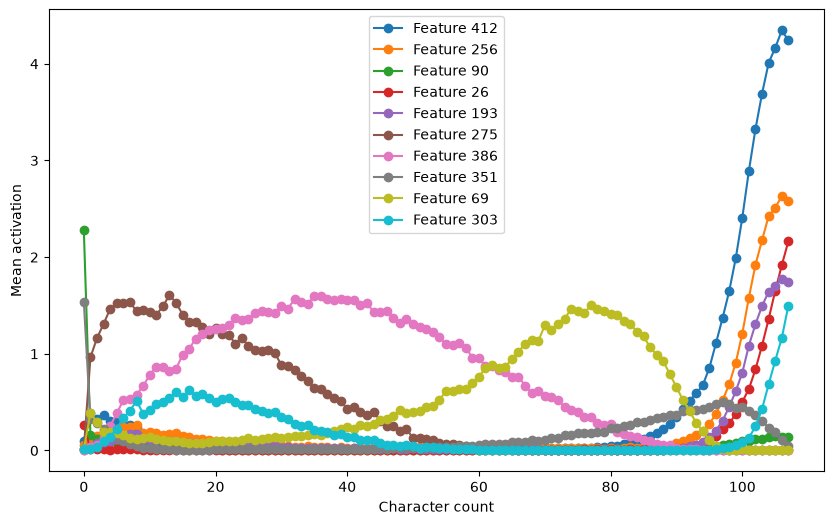

In [19]:
k = 10

# Top-k feature indices
top_features = torch.topk(metrics_tensor, k).indices.tolist()

plt.figure(figsize=(10, 6))

for feature in top_features:
    plt.plot(
        count_values.numpy(),
        means_by_count[:, feature].numpy(),
        marker="o",
        label=f"Feature {feature}",
    )

plt.xlabel("Character count")
plt.ylabel("Mean activation")
plt.legend()
plt.show()